In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

if root_path not in sys.path:
    sys.path.append(root_path)
    
from src.cleaning.marcenko_pastur import MarcenkoPastur
from src.cleaning.optimal_rie import OptimalRIE
from src.alpha.backtester import OutOfSampleEngine
from src.stats.ic_analyzer import ICAnalyzer
from src.stats.risk_metrics import RiskMetrics

# 设置绘图风格，模拟专业报告
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = ['Arial']

In [30]:
def generate_synthetic_market_data(n_days=1000, n_assets=1000, n_factors=3):
    np.random.seed(42)
    # 模拟真实的日收益率量级 (通常在 -3% 到 +3% 之间)
    # 因子收益
    factors = np.random.normal(0, 0.01, (n_days, n_factors)) 
    loadings = np.random.normal(0, 0.5, (n_factors, n_assets))
    
    # 特点：降低噪声标准差到 0.02 (2% 的日波动)
    signal = factors @ loadings
    noise = np.random.normal(0, 0.02, (n_days, n_assets)) 
    
    returns = signal + noise
    
    dates = pd.date_range(start='2020-01-01', periods=n_days, freq='B')
    df = pd.DataFrame(returns, index=dates, columns=[f'Asset_{i}' for i in range(n_assets)])
    
    # 存为 csv
    df.to_csv('../data/market_evolution_tracks.csv')
    return df

df = generate_synthetic_market_data()

In [31]:
def plot_spectral_analysis(returns_df):
    # 计算样本相关矩阵及其特征值
    corr_matrix = returns_df.corr().values
    evals, _ = np.linalg.eigh(corr_matrix)
    evals = evals[::-1] # 降序
    
    Q = len(returns_df) / returns_df.shape[1] # T/N
    sigma_sq = MarcenkoPastur.estimate_sigma_sq(evals, Q)
    l_min, l_max = MarcenkoPastur.get_theoretical_edge(sigma_sq, Q)

    # 绘图
    plt.figure(figsize=(10, 6))
    plt.hist(evals, bins=80, density=True, alpha=0.6, color='skyblue', label='Empirical Eigenvalues')
    
    # 绘制 MP 理论红线
    x = np.linspace(l_min, l_max, 500)
    y = MarcenkoPastur.pdf(x, sigma_sq, Q)
    plt.plot(x, y, 'r-', lw=2, label=f'MP Distribution (Q={Q:.2f})')
    
    plt.axvline(l_max, color='orange', linestyle='--', label='Noise Ceiling (Lambda+)')
    plt.title("Spectral Density: Financial Returns vs. Marcenko-Pastur Law")
    plt.xlabel("Eigenvalue")
    plt.ylabel("Density")
    plt.legend()
    plt.yscale('log') # 金融数据离群值大，对数坐标更清晰
    plt.show()

d:\OneDrive\works\RMT-Clean-Alpha\RMT-Clean-Alpha\src\cleaning\marcenko_pastur.py:27: RuntimeWarning: divide by zero encountered in divide
  res = (Q / (2 * np.pi * sigma_sq * x)) * np.sqrt(np.maximum(0, (l_max - x) * (x - l_min)))
d:\OneDrive\works\RMT-Clean-Alpha\RMT-Clean-Alpha\src\cleaning\marcenko_pastur.py:27: RuntimeWarning: invalid value encountered in multiply
  res = (Q / (2 * np.pi * sigma_sq * x)) * np.sqrt(np.maximum(0, (l_max - x) * (x - l_min)))


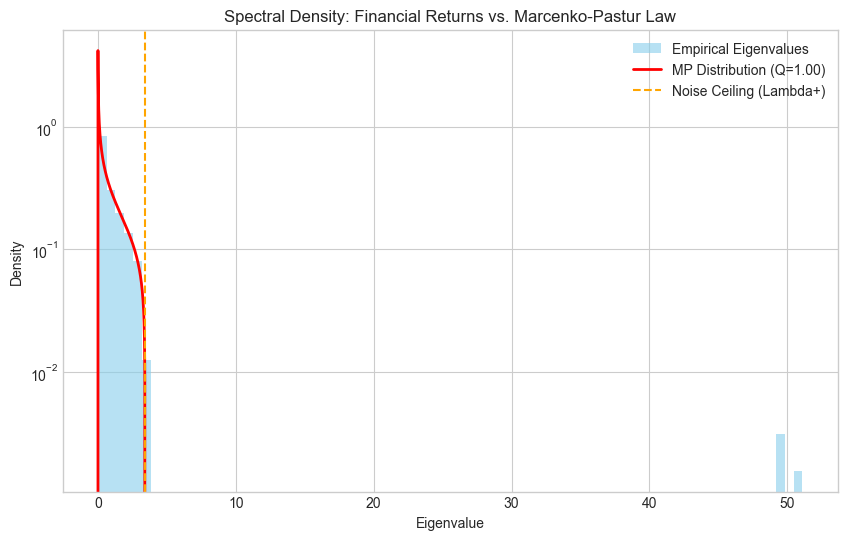

回测完成，样本外收益率已生成。


In [32]:
if 'df' not in locals():
    df = pd.read_csv('../data/market_evolution_tracks.csv', index_col=0, parse_dates=True)
plot_spectral_analysis(df)
# 1. 启动严格隔离的滚动回测
engine = OutOfSampleEngine(df, window_size=252)
oos_returns, oos_weights = engine.run_rolling_cleaning()

print("回测完成，样本外收益率已生成。")

# 2. 计算基准（未去噪的样本矩阵）作为对比
base_returns, _ = engine.run_rolling_cleaning(method='sample') 

# 3. 计算风险指标
risk_report = RiskMetrics.calculate_all(oos_returns)


# 4. 计算信息系数（IC）分析
oos_weights.index = df.index[252 : -1] 
shifted_returns = df.shift(-1) 
ic_report = ICAnalyzer.analyze(oos_weights, shifted_returns)

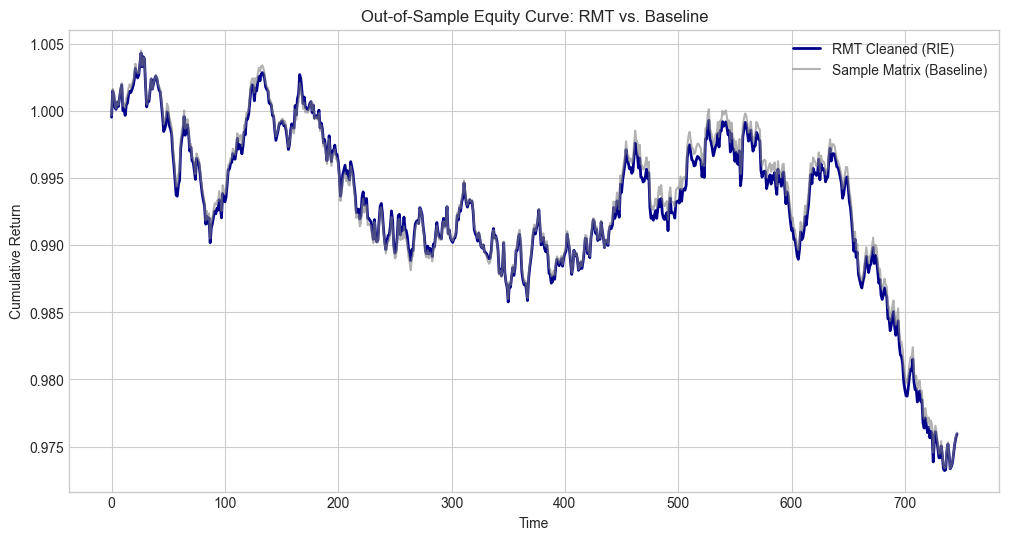

In [33]:
def plot_performance(oos_returns, base_returns=None):
    plt.figure(figsize=(12, 6))
    
    # RMT 清洗后的净值
    cum_rmt = (1 + oos_returns).cumprod()
    plt.plot(cum_rmt, label='RMT Cleaned (RIE)', color='darkblue', lw=2)
    
    # 基准净值
    if base_returns is not None:
        cum_base = (1 + base_returns).cumprod()
        plt.plot(cum_base, label='Sample Matrix (Baseline)', color='gray', alpha=0.6)
    
    plt.title("Out-of-Sample Equity Curve: RMT vs. Baseline")
    plt.xlabel("Time")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.show()

plot_performance(oos_returns, base_returns)

In [34]:
print("="*50)
print("             QUANT RESEARCH REPORT              ")
print("="*50)
print(f"{'Metric':<25} | {'Value':<15}")
print("-" * 45)
print(f"{'Mean Rank IC':<25} | {ic_report['Mean Rank IC']:>15.4f}")
print(f"{'IC t-stat':<25} | {ic_report['IC t-stat']:>15.2f}")
print(f"{'P-value':<25} | {ic_report['p-value']:>15.4f}")
print("-" * 45)
print(f"{'Annualized Return':<25} | {risk_report['Annualized Return']:>15.2%}")
print(f"{'Sharpe Ratio':<25} | {risk_report['Sharpe Ratio']:>15.2f}")
print(f"{'Max Drawdown':<25} | {risk_report['Max Drawdown']:>15.2%}")
print("="*50)

             QUANT RESEARCH REPORT              
Metric                    | Value          
---------------------------------------------
Mean Rank IC              |          0.0028
IC t-stat                 |            2.13
P-value                   |          0.0335
---------------------------------------------
Annualized Return         |          -0.81%
Sharpe Ratio              |           -0.65
Max Drawdown              |          -3.10%


In [35]:
# 调试 1: 检查权重是否有问题
print("Weights Summary:")
print(oos_weights.iloc[0].describe()) # 查看第一天的权重分布

# 调试 2: 检查是否有极端收益率
print("\nMax Daily Return:", oos_returns.max())
print("Min Daily Return:", oos_returns.min())

# 调试 3: 检查 RMT 修正了什么
in_sample = df.iloc[:252]
c_orig = in_sample.corr().values
cleaner = OptimalRIE(c_orig, 252/50)
c_clean, _ = cleaner.clean()
print("\nMatrix Difference (Frobenius Norm):", np.linalg.norm(c_orig - c_clean))

Weights Summary:
count    1000.000000
mean        0.001000
std         0.000568
min        -0.001179
25%         0.000611
50%         0.001005
75%         0.001355
max         0.002759
Name: 2020-12-18 00:00:00, dtype: float64

Max Daily Return: 0.002872044786287357
Min Daily Return: -0.0026066380879886967

Matrix Difference (Frobenius Norm): 10.97950901848184
